# Stage 09: Feature Engineering

This notebook creates model-ready features for the S&P 500 volatility project. The target is future five-trading-day realized volatility, while every predictor is built from information available at or before date `t`.

## Assignment Alignment

The Stage 09 homework asks for at least three engineered features, including at least one categorical encoding. For each feature, this notebook includes implementation code, a rationale tied to Stage 08 EDA, and a correlation check against the target variable.

In [1]:
import json
import os
from pathlib import Path
import sys

REPO_ROOT = next(
    parent for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "homework" / "homework09").exists()
)
HOMEWORK_DIR = REPO_ROOT / "homework" / "homework09"
STAGE08_DIR = REPO_ROOT / "homework" / "homework08"
STAGE06_DIR = REPO_ROOT / "homework" / "homework06"

os.environ.setdefault("MPLCONFIGDIR", str(REPO_ROOT.parent / "tmp" / "stage09-matplotlib"))

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv

load_dotenv(HOMEWORK_DIR / ".env")
PROCESSED_DIR = HOMEWORK_DIR / os.environ.get("DATA_DIR_PROCESSED", "data/processed")
REPORTS_DIR = HOMEWORK_DIR / os.environ.get("REPORTS_DIR", "reports")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(HOMEWORK_DIR / "src"))
from features import (
    TARGET_COLUMN,
    create_time_series_features,
    summarize_feature_target_relationships,
    validate_model_ready_data,
)

plt.style.use("seaborn-v0_8-whitegrid")

## Load Project Data

The input is the cleaned Stage 06 price dataset. Stage 08 EDA found no missing values in the cleaned data, a short January 2025 sample, a positive overall price move, and daily-return variation with one larger negative move. Those observations guide the feature choices below.

In [2]:
source_path = STAGE06_DIR / "data" / "processed" / "sp500_prices_cleaned.parquet"
if not source_path.exists():
    fallback_files = sorted((STAGE06_DIR / "data" / "processed").glob("sp500_prices_cleaned_*.parquet"))
    if not fallback_files:
        raise FileNotFoundError("Run Stage 06 first so cleaned price data are available.")
    source_path = fallback_files[-1]

cleaned_prices = pd.read_parquet(source_path).sort_values("date").reset_index(drop=True)
cleaned_prices[["date", "ticker", "close", "volume", "daily_return"]].head()

,date,ticker,close,volume,daily_return
0,2025-01-02,^GSPC,5868.55,3621680000,0.0
1,2025-01-03,^GSPC,5942.47,3667340000,0.012596
2,2025-01-06,^GSPC,5975.38,4940120000,0.005538
3,2025-01-07,^GSPC,5909.03,4517330000,-0.011104
4,2025-01-08,^GSPC,5986.02,4441740000,0.013029


## Engineer Features

The helper module `src/features.py` creates more than the required three features. The core groups are return lags, rolling return statistics, volume transformations, price-relative features, weekday one-hot indicators, and one interaction feature. The weekday columns satisfy the categorical-encoding requirement.

In [3]:
engineered_data, feature_columns, feature_registry = create_time_series_features(cleaned_prices)
model_ready_data = engineered_data.dropna(subset=feature_columns + [TARGET_COLUMN]).copy()
validation_results = validate_model_ready_data(model_ready_data, feature_columns)

print("Full rows:", len(engineered_data))
print("Model-ready rows:", len(model_ready_data))
print("Number of engineered feature columns:", len(feature_columns))
print("Validation:", validation_results)

model_ready_data[["date"] + feature_columns + [TARGET_COLUMN]].head()

Full rows: 19
Model-ready rows: 8
Number of engineered feature columns: 14
Validation: {'features_present': True, 'no_missing_features_or_target': True, 'finite_numeric_features': True, 'dates_sorted': True, 'nonnegative_target': True}


,date,return_lag_1,return_lag_3,return_rolling_mean_3,return_rolling_volatility_5,volume_pct_change_1,volume_relative_to_5d,log_volume,close_relative_to_3d,return_lag_1_x_volume_change_1,weekday_Friday,weekday_Monday,weekday_Thursday,weekday_Tuesday,weekday_Wednesday,future_5d_realized_volatility
6,2025-01-13,-0.026559,-0.011104,-0.008211,0.015358,-0.069599,0.990481,22.209677,-0.012043,0.001848,0,1,0,0,0,0.007171
7,2025-01-14,0.001575,0.013029,-0.003985,0.013930,-0.063087,0.897673,22.144512,-0.00683,-0.000099,0,0,0,1,0,0.006579
8,2025-01-15,0.001146,-0.026559,-0.007946,0.013462,0.097118,1.020129,22.237199,0.019625,0.000111,0,0,0,0,1,0.004223
9,2025-01-16,0.018313,0.001575,0.007011,0.015511,-0.023671,0.994765,22.213243,0.010379,-0.000433,0,0,1,0,0,0.004497
10,2025-01-17,-0.002113,0.001146,0.005782,0.014404,-0.015814,0.979243,22.197303,0.014654,0.000033,1,0,0,0,0,0.005532


## Feature Rationale Linked to Stage 08

This table documents each engineered feature, the Stage 08 EDA insight that motivated it, and how look-ahead leakage is avoided.

In [4]:
rationale_rows = []
for feature in feature_columns:
    detail = feature_registry[feature]
    rationale_rows.append(
        {
            "feature": feature,
            "definition": detail["definition"],
            "stage08_eda_link": detail["eda_link"],
            "rationale": detail["rationale"],
            "leakage_note": detail["leakage_note"],
        }
    )

feature_rationale = pd.DataFrame(rationale_rows)
feature_rationale

,feature,definition,stage08_eda_link,rationale,leakage_note
0,return_lag_1,Daily return at t-1.,Stage 08 return distribution and time-series p...,Stage 08 showed daily returns move around a ne...,Uses only the previous trading day's return.
1,return_lag_3,Daily return at t-3.,Stage 08 time-series movement in daily returns.,Adds short-memory return behavior without dupl...,Uses only the return three trading days before...
2,return_rolling_mean_3,Mean return from t-3 through t-1.,Stage 08 found return volatility and short sam...,Smooths noisy daily returns into a recent dire...,"Returns are shifted before rolling, so the cur..."
3,return_rolling_volatility_5,Population standard deviation of returns from ...,Stage 08 distribution and boxplot highlighted ...,Recent realized volatility is a natural predic...,Uses only prior returns.
4,volume_pct_change_1,Current volume percent change from t-1.,Stage 08 volume distribution showed variation ...,Sudden activity changes can coincide with mark...,Uses current volume and the previous day's vol...
5,volume_relative_to_5d,Current volume divided by mean volume from t-5...,Stage 08 volume analysis suggested scale diffe...,Compares today's trading activity with recent ...,The comparison baseline uses only prior volume.
6,log_volume,Natural logarithm of current volume.,Stage 08 descriptive statistics showed volume ...,Reduces the scale of large volume counts while...,Uses only current-date volume.
7,close_relative_to_3d,Current close relative to the mean close from ...,Stage 08 price trend plot showed short-run lev...,Measures whether price is extended relative to...,The denominator uses only prior closes.
8,return_lag_1_x_volume_change_1,Lagged return multiplied by current one-day vo...,"Stage 08 bivariate checks considered return, v...","Combines direction and activity, allowing high...",Uses lagged return and current volume change o...
9,weekday_Friday,One-hot indicator for Friday.,Stage 08 noted the sample is chronological and...,Encodes the categorical day-of-week field requ...,Calendar information is known at date t.


## Correlation Checks Against the Target

The assignment asks for a plot or correlation check for each feature. Because the model-ready sample is small, these correlations are used only as screening evidence. They should not be interpreted as stable model findings.

In [5]:
feature_target_checks = summarize_feature_target_relationships(
    model_ready_data,
    feature_columns,
    target_column=TARGET_COLUMN,
)

feature_target_checks[[
    "feature",
    "correlation_with_target",
    "n_observations",
    "interpretation",
]]

,feature,correlation_with_target,n_observations,interpretation
7,close_relative_to_3d,-0.883947,8,close_relative_to_3d has a strong negative sam...
0,return_lag_1,-0.745595,8,return_lag_1 has a strong negative sample corr...
10,weekday_Monday,0.694795,8,weekday_Monday has a moderate positive sample ...
4,volume_pct_change_1,-0.596569,8,volume_pct_change_1 has a moderate negative sa...
8,return_lag_1_x_volume_change_1,0.578386,8,return_lag_1_x_volume_change_1 has a moderate ...
2,return_rolling_mean_3,-0.535566,8,return_rolling_mean_3 has a moderate negative ...
11,weekday_Thursday,-0.530701,8,weekday_Thursday has a moderate negative sampl...
3,return_rolling_volatility_5,0.496382,8,return_rolling_volatility_5 has a moderate pos...
5,volume_relative_to_5d,-0.445739,8,volume_relative_to_5d has a moderate negative ...
6,log_volume,-0.441983,8,log_volume has a moderate negative sample corr...


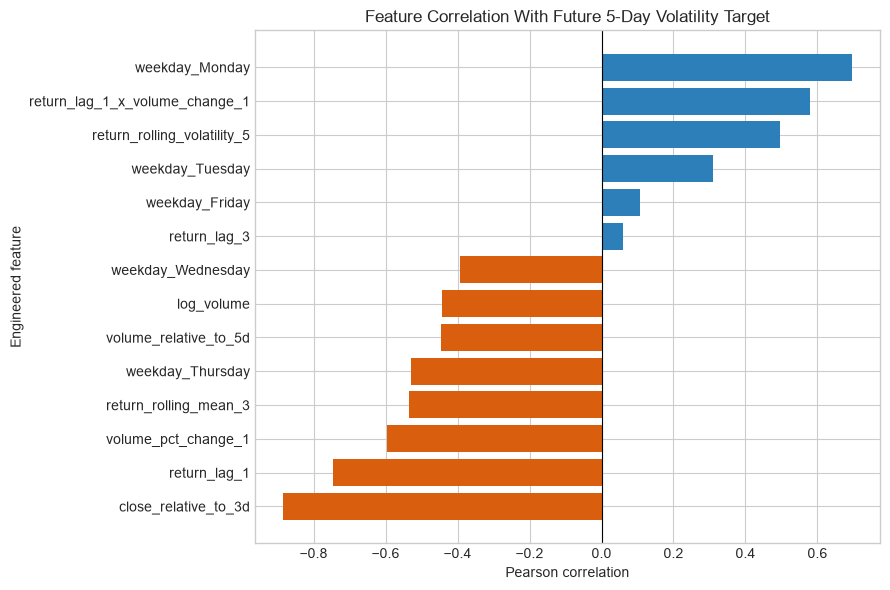

In [6]:
plot_data = feature_target_checks.dropna(subset=["correlation_with_target"]).copy()
plot_data = plot_data.sort_values("correlation_with_target")

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#2c7fb8" if value >= 0 else "#d95f0e" for value in plot_data["correlation_with_target"]]
ax.barh(plot_data["feature"], plot_data["correlation_with_target"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Feature Correlation With Future 5-Day Volatility Target")
ax.set_xlabel("Pearson correlation")
ax.set_ylabel("Engineered feature")
plt.tight_layout()
correlation_plot_path = REPORTS_DIR / "feature_target_correlations.png"
plt.savefig(correlation_plot_path, dpi=150)
plt.show()

## Visual Check of Feature Construction

The first plot compares the daily return with the prior-only rolling volatility feature. The second plot shows the future target separately to make clear that the target is not used as a predictor.

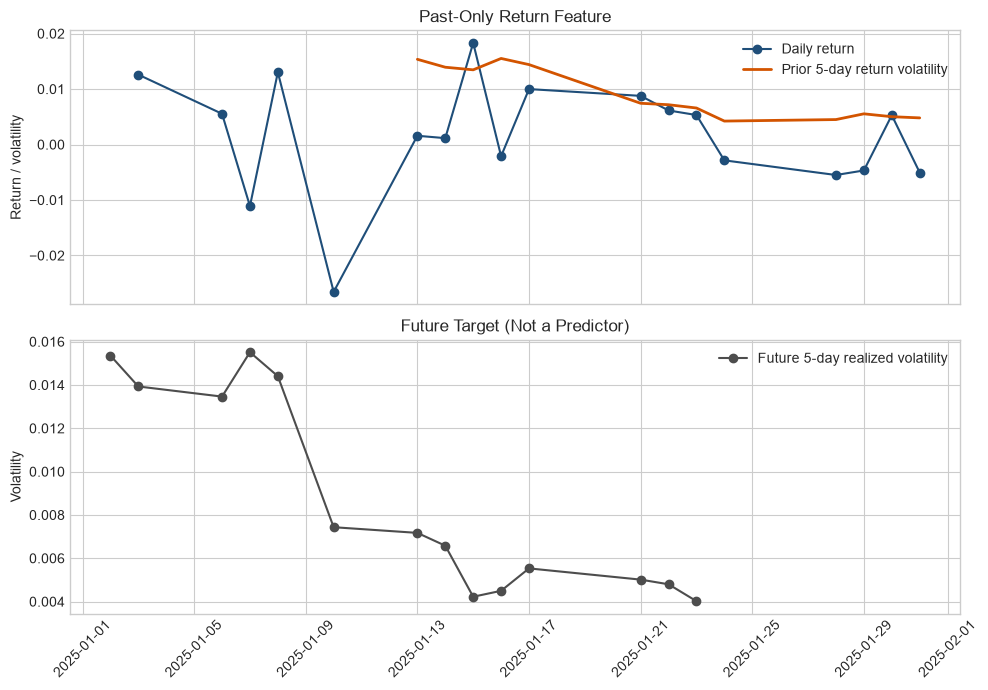

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].plot(engineered_data["date"], engineered_data["daily_return"], marker="o", label="Daily return", color="#1f4e79")
axes[0].plot(engineered_data["date"], engineered_data["return_rolling_volatility_5"], linewidth=2, label="Prior 5-day return volatility", color="#d35400")
axes[0].set_title("Past-Only Return Feature")
axes[0].set_ylabel("Return / volatility")
axes[0].legend()

axes[1].plot(engineered_data["date"], engineered_data[TARGET_COLUMN], marker="o", label="Future 5-day realized volatility", color="#4d4d4d")
axes[1].set_title("Future Target (Not a Predictor)")
axes[1].set_ylabel("Volatility")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()

plt.tight_layout()
feature_plot_path = REPORTS_DIR / "feature_target_overview.png"
plt.savefig(feature_plot_path, dpi=150)
plt.show()

## Save Reproducible Outputs

Stable filenames make the GitHub submission easy to inspect and avoid stale timestamped artifacts. The full table preserves expected initial and final gaps from lag/target construction; the model-ready table drops only rows without the selected predictors or target.

In [8]:
full_parquet_path = PROCESSED_DIR / "engineered_features_full.parquet"
model_ready_csv_path = PROCESSED_DIR / "model_ready_features.csv"
model_ready_parquet_path = PROCESSED_DIR / "model_ready_features.parquet"
registry_path = PROCESSED_DIR / "feature_registry.json"
checks_path = PROCESSED_DIR / "feature_target_checks.csv"
metadata_path = PROCESSED_DIR / "feature_engineering_metadata.json"
rationale_path = PROCESSED_DIR / "feature_rationale.csv"

engineered_data.to_parquet(full_parquet_path, index=False)
model_ready_data.to_csv(model_ready_csv_path, index=False)
model_ready_data.to_parquet(model_ready_parquet_path, index=False)
feature_target_checks.to_csv(checks_path, index=False)
feature_rationale.to_csv(rationale_path, index=False)
registry_path.write_text(json.dumps(feature_registry, indent=2), encoding="utf-8")

def repo_path(path):
    return path.relative_to(REPO_ROOT).as_posix()


metadata = {
    "source_file": repo_path(source_path),
    "full_rows": int(len(engineered_data)),
    "model_ready_rows": int(len(model_ready_data)),
    "feature_columns": feature_columns,
    "target_column": TARGET_COLUMN,
    "validation_results": validation_results,
    "outputs": {
        "full_parquet": repo_path(full_parquet_path),
        "model_ready_csv": repo_path(model_ready_csv_path),
        "model_ready_parquet": repo_path(model_ready_parquet_path),
        "feature_registry": repo_path(registry_path),
        "feature_rationale": repo_path(rationale_path),
        "feature_target_checks": repo_path(checks_path),
        "correlation_plot": repo_path(correlation_plot_path),
        "feature_plot": repo_path(feature_plot_path),
    },
}
metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

reloaded_model_ready = pd.read_parquet(model_ready_parquet_path)
assert reloaded_model_ready.shape == model_ready_data.shape
assert validate_model_ready_data(reloaded_model_ready, feature_columns) == validation_results

print("Saved stable Stage 09 outputs.")
print("Top 5 absolute correlations:")
print(feature_target_checks[["feature", "correlation_with_target"]].head().to_string(index=False))

Saved stable Stage 09 outputs.
Top 5 absolute correlations:
                       feature  correlation_with_target
          close_relative_to_3d                -0.883947
                  return_lag_1                -0.745595
                weekday_Monday                 0.694795
           volume_pct_change_1                -0.596569
return_lag_1_x_volume_change_1                 0.578386


## Interpretation and Next Step

Top screening signals in this small sample are `close_relative_to_3d`, `return_lag_1`, `weekday_Monday`, `volume_pct_change_1`, and `return_lag_1_x_volume_change_1`. These results are useful for deciding what to carry into modeling, but the sample has only eight model-ready rows after lag and future-target requirements.

Practical implication: Stage 10 should collect a longer historical window before training, use chronological train/test splitting, and keep the future-volatility target separate from all predictors to avoid look-ahead leakage.